<a href="https://www.kaggle.com/code/riteshkumarweb/polynominal-linear-regression?scriptVersionId=309942235" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mirajdeepbhandari/polynomial-regression/Ice_cream selling data.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/mirajdeepbhandari/polynomial-regression/Ice_cream selling data.csv')

In [3]:
df

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [4]:
X = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [5]:
X

,Temperature (°C)
0,-4.662263
1,-4.316559
2,-4.213985
3,-3.949661
4,-3.578554
5,-3.455712
6,-3.108440
7,-3.081303
8,-2.672461
9,-2.652287


In [6]:
y

0     41.842986
1     34.661120
2     39.383001
3     37.539845
4     32.284531
5     30.001138
6     22.635401
7     25.365022
8     19.226970
9     20.279679
10    13.275828
11    18.123991
12    11.218294
13    10.012868
14    12.615181
15    10.957731
16     6.689123
17     9.392969
18     5.210163
19     4.673643
20     0.328626
21     0.897603
22     3.165600
23     1.931416
24     2.576782
25     4.625689
26     0.789974
27     2.313806
28     1.292361
29     0.953115
30     3.782570
31     4.857988
32     8.943823
33     8.170735
34     7.412094
35    10.336631
36    15.996620
37    12.568237
38    21.342916
39    20.114413
40    22.839406
41    16.983279
42    25.142082
43    26.104740
44    28.912188
45    17.843957
46    34.530743
47    27.698383
48    41.514822
Name: Ice Cream Sales (units), dtype: float64

In [7]:
import matplotlib.pyplot as plt 

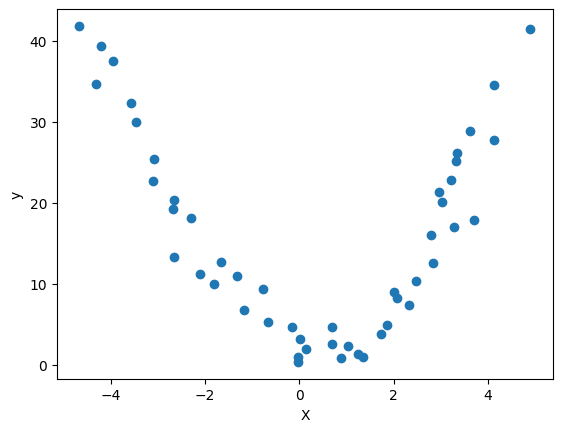

In [8]:
plt.scatter(X,y,)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

# X = your features, y = your target labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

In [10]:
X_train

,Temperature (°C)
12,-2.111870
4,-3.578554
34,2.318591
8,-2.672461
3,-3.949661
6,-3.108440
40,3.211366
41,3.270044
46,4.130868
15,-1.326379


In [11]:
y_train

12    11.218294
4     32.284531
34     7.412094
8     19.226970
3     37.539845
6     22.635401
40    22.839406
41    16.983279
46    34.530743
15    10.957731
9     20.279679
16     6.689123
24     2.576782
33     8.170735
30     3.782570
0     41.842986
43    26.104740
32     8.943823
5     30.001138
29     0.953115
11    18.123991
36    15.996620
1     34.661120
21     0.897603
2     39.383001
37    12.568237
35    10.336631
23     1.931416
39    20.114413
10    13.275828
22     3.165600
18     5.210163
48    41.514822
20     0.328626
7     25.365022
42    25.142082
14    12.615181
28     1.292361
38    21.342916
Name: Ice Cream Sales (units), dtype: float64

In [12]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [13]:
# 3. Make predictions
y_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred)
print(f'The R2_score is {score} This' )

The R2_score is -0.5751270190188227 This


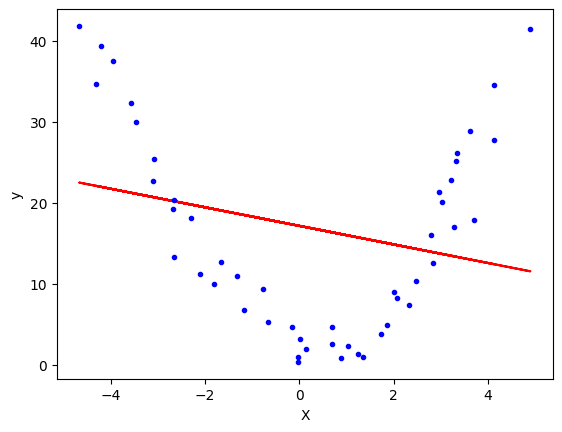

In [15]:
# 📦 Plot the regression prediction line
# X_train → input training values
# model.predict(X_train) → predicted y values from the trained model

# 🔴 color='r' means the prediction line will be RED
plt.plot(X_train, model.predict(X_train), color='r')


# 🔵 Plot the original dataset points
# X → input values
# y → actual target values

# "b." means:
# b → blue color
# . → dot markers (scatter style points)
plt.plot(X, y, "b.")


# 🏷️ Label the x-axis
# This text will appear below the horizontal axis
plt.xlabel("X")


# 🏷️ Label the y-axis
# This text will appear on the vertical axis
plt.ylabel("y")


# 👁️ Display the plot window
# Without this, the graph may not appear in some environments
plt.show()

In [16]:
# 📦 Import PolynomialFeatures class from sklearn.preprocessing
# This tool helps convert simple input features (like x)
# into polynomial features (x², x³, etc.)
from sklearn.preprocessing import PolynomialFeatures


# 🔁 Applying Polynomial Linear Regression
# Here we are preparing to transform our data so that
# a linear model can learn curved relationships.

# 🎯 degree=2 means we want features up to x²
# Example:
# If X = [x]
# It will become → [x, x²]

# 🚫 include_bias=False means:
# Do NOT add the constant column "1"
# because LinearRegression will automatically handle the intercept.

poly = PolynomialFeatures(degree=2, include_bias=False)


# 🧠 fit_transform does TWO things:
# 1️⃣ fit → learn how to create polynomial combinations
# 2️⃣ transform → actually convert X_train into polynomial features

# Example transformation:
# If X_train = [[2], [3], [4]]
# After transform → [[2,4], [3,9], [4,16]]

# So now the model can learn curved relationships.
X_train_trans = poly.fit_transform(X_train)


# 🔄 transform the TEST data using the SAME polynomial structure
# Important rule in ML:
# ❗ Only fit on training data
# ❗ Test data must only be transformed

# Example:
# X_test = [[5]]
# becomes → [[5,25]]

X_test_trans = poly.transform(X_test)

In [17]:
X_train_trans


array([[-2.11186969e+00,  4.45999359e+00],
       [-3.57855372e+00,  1.28060467e+01],
       [ 2.31859124e+00,  5.37586534e+00],
       [-2.67246083e+00,  7.14204687e+00],
       [-3.94966109e+00,  1.55998227e+01],
       [-3.10844012e+00,  9.66239999e+00],
       [ 3.21136614e+00,  1.03128725e+01],
       [ 3.27004407e+00,  1.06931882e+01],
       [ 4.13086796e+00,  1.70640701e+01],
       [-1.32637898e+00,  1.75928121e+00],
       [-2.65228679e+00,  7.03462523e+00],
       [-1.17312327e+00,  1.37621820e+00],
       [ 6.88780908e-01,  4.74419139e-01],
       [ 2.07510060e+00,  4.30604249e+00],
       [ 1.74000001e+00,  3.02760004e+00],
       [-4.66226268e+00,  2.17366933e+01],
       [ 3.33593241e+00,  1.11284451e+01],
       [ 1.99931037e+00,  3.99724195e+00],
       [-3.45571170e+00,  1.19419433e+01],
       [ 1.35981267e+00,  1.84909051e+00],
       [-2.28826400e+00,  5.23615213e+00],
       [ 2.78483646e+00,  7.75531413e+00],
       [-4.31655945e+00,  1.86326855e+01],
       [-3.

In [18]:
# 📦 Create a Linear Regression model object
# This model will learn the relationship between input features and the target value
lr = LinearRegression()


# 🧠 Train (fit) the model using the TRAINING data
# X_train_trans → polynomial features (x, x² because degree=2)
# y_train → actual target values

# During training the model calculates coefficients:
# y = β0 + β1*x + β2*x²

lr.fit(X_train_trans, y_train)


# 🖨️ When you run the model object in a notebook,
# it simply prints the model type
LinearRegression()


# 🔮 Use the trained model to make predictions
# X_test_trans → transformed test features

# The model applies the learned formula:
# y_pred = β0 + β1*x + β2*x²

y_pred = lr.predict(X_test_trans)


# 📊 Evaluate model performance using R² score
# R² measures how well the model explains the variance in the data

# Formula idea:
# R² = 1 → perfect prediction
# R² = 0 → model is no better than predicting the mean
# R² < 0 → very poor model

r2_score(y_test, y_pred)

0.843055137193884

In [19]:
# 🧠 Print the learned coefficients (weights) of the model
# These correspond to the importance of each feature

print(lr.coef_)  

[-0.70641926  1.87145125]


In [20]:
# 🎯 Access the intercept (β0)
# This is the constant value added to the prediction
print(lr.intercept_)

2.768305829573862


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


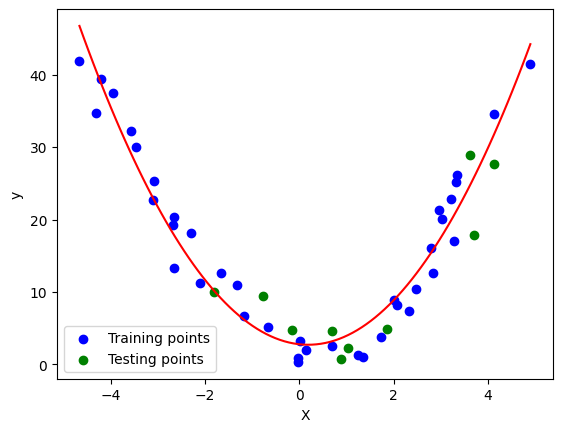

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# create smooth X values using your original X
X_range = np.linspace(X.min(), X.max(), 100).reshape(100,1)

# convert them to polynomial features
X_range_poly = poly.transform(X_range)

# predict y values
y_pred = lr.predict(X_range_poly)

# plot regression curve
plt.plot(X_range, y_pred, color='red')

# plot training points
plt.scatter(X_train, y_train, color='blue', label='Training points')

# plot testing points
plt.scatter(X_test, y_test, color='green', label='Testing points')

plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()